In [1]:
import pandas as pd
df = pd.read_csv(r'C:\Users\kelav\OneDrive\Документы\projects\uscis_analysis\data\exports\uscis_quarterly_e11_niw.csv') #вручную с 22 года на основе RADP 

totals_auto = pd.read_csv(r"C:\Users\kelav\OneDrive\Документы\projects\uscis_analysis\data\analysis_tables\eb1eb2_total_radp.csv")
i140_yearly_total_eb1_eb2_snapshots = pd.read_csv(r'C:/Users/kelav/OneDrive/Документы/projects/uscis_analysis/data/analysis_tables/i140_yearly_total_eb1_eb2_snapshots.csv')

In [2]:
df['approval_rate_%'] = df.approved/df.received*100
df['denial_rate_%'] = df.denied/df.received*100
df['pending_rate_%'] = df.pending/df.received*100
df['deny_approval_ratio'] = df.denied/df.approved




In [3]:
df

,type,fiscal_year,fiscal_quarter,received,approved,denied,pending,approval_rate_%,denial_rate_%,pending_rate_%,deny_approval_ratio
0,TOTAL,2024,1,55590,38696,4320,71049,69.609642,7.771182,127.808958,0.111639
1,TOTAL,2024,2,61386,42554,5269,85806,69.321995,8.583390,139.781058,0.123819
2,TOTAL,2024,3,54487,39608,4851,96997,72.692569,8.903041,178.018610,0.122475
3,TOTAL,2024,4,56835,38248,5521,112206,67.296560,9.714085,197.424122,0.144347
4,Alien of Extraordinary Ability (E11),2024,1,4704,2928,1067,8088,62.244898,22.682823,171.938776,0.364413
5,Alien of Extraordinary Ability (E11),2024,2,5364,3112,1263,8992,58.016406,23.545861,167.636092,0.405848
6,Alien of Extraordinary Ability (E11),2024,3,4331,2857,1225,9210,65.966290,28.284461,212.652967,0.428771
7,Alien of Extraordinary Ability (E11),2024,4,5767,3334,1148,10586,57.811687,19.906364,183.561644,0.344331
8,National Interest Waiver (NIW),2024,1,14264,7996,2423,22756,56.057207,16.986820,159.534492,0.303027
9,National Interest Waiver (NIW),2024,2,16437,8052,2572,28694,48.987041,15.647624,174.569569,0.319424


In [4]:
df_totals = df.groupby(['type', 'fiscal_year'], as_index=False)[['received', 'denied', 'approved', 'pending']].sum()

In [5]:
df_totals
df_totals['approval_rate_%'] = df_totals.approved/df_totals.received*100
df_totals['denial_rate_%'] = df_totals.denied/df_totals.received*100
df_totals['pending_rate_%'] = df_totals.pending/df_totals.received*100
df_totals['deny_approval_ratio'] = df_totals.denied/df_totals.approved
# Таблица построена на основании RADP данных
df_totals.sort_values('fiscal_year')

,type,fiscal_year,received,denied,approved,pending,approval_rate_%,denial_rate_%,pending_rate_%,deny_approval_ratio
0,Alien of Extraordinary Ability (E11),2022,10481,1608,5623,24406,53.649461,15.342048,232.859460,0.285968
4,National Interest Waiver (NIW),2022,21973,468,10316,80546,46.948528,2.129887,366.568061,0.045366
8,TOTAL,2022,165300,4003,139644,333291,84.479129,2.421658,201.627949,0.028666
5,National Interest Waiver (NIW),2023,39803,8172,31889,71413,80.117077,20.531116,179.416124,0.256264
9,TOTAL,2023,189028,19637,168590,207658,89.187845,10.388408,109.855683,0.116478
1,Alien of Extraordinary Ability (E11),2023,15905,4156,10356,27892,65.111600,26.130148,175.366237,0.401313
6,National Interest Waiver (NIW),2024,63549,11256,27526,129661,43.314608,17.712316,204.033108,0.408922
2,Alien of Extraordinary Ability (E11),2024,20166,4703,12231,36876,60.651592,23.321432,182.862243,0.384515
10,TOTAL,2024,228298,19961,159106,366058,69.692244,8.743397,160.342184,0.125457
3,Alien of Extraordinary Ability (E11),2025,29582,6165,12468,68857,42.147252,20.840376,232.766547,0.494466


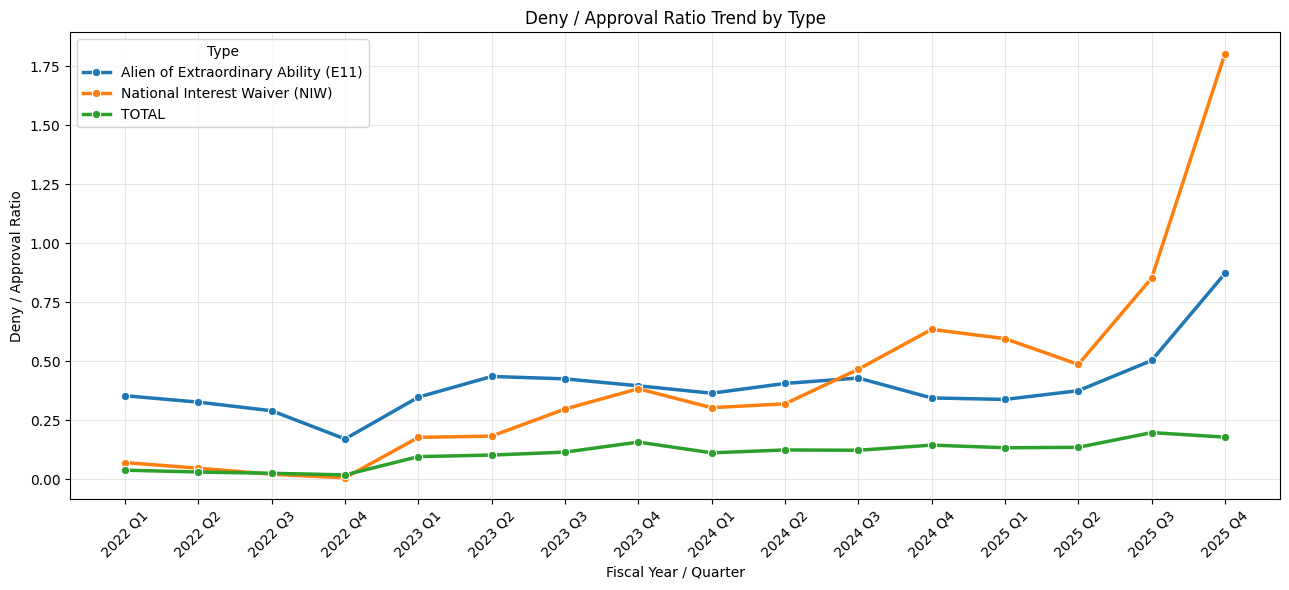

In [37]:
#Построим тренды по доле отказам
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = df.copy()

# нормальная временная ось: FY2024 Q1, FY2024 Q2 и т.д.
df_plot['fyq'] = (
    df_plot['fiscal_year'].astype(str)
    + ' Q'
    + df_plot['fiscal_quarter'].astype(str)
)

df_plot = df_plot.sort_values(['fiscal_year', 'fiscal_quarter', 'type'])

plt.figure(figsize=(13, 6))

sns.lineplot(
    data=df_plot,
    x='fyq',
    y='deny_approval_ratio',
    hue='type',
    marker='o',
    linewidth=2.5
)

plt.title('Deny / Approval Ratio Trend by Type')
plt.xlabel('Fiscal Year / Quarter')
plt.ylabel('Deny / Approval Ratio')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend(title='Type')
plt.tight_layout()
plt.show()

#Очен наглядно виден взлетевший тренд на увеличение доли отказов

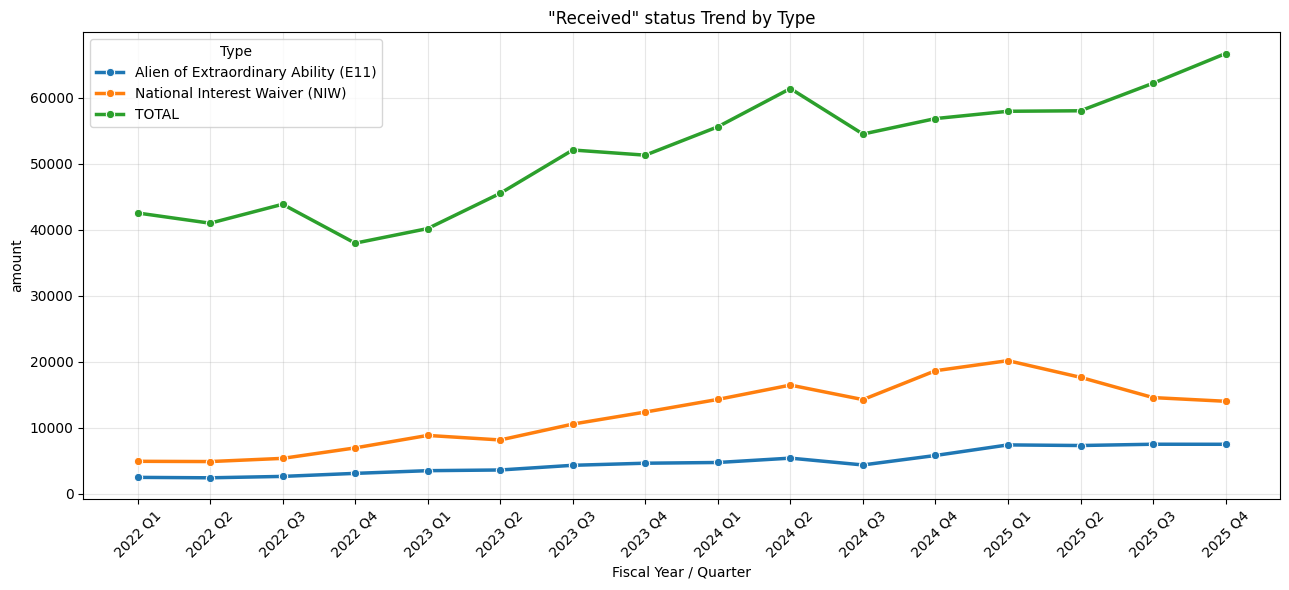

In [39]:
#Посмотрим по статусу Received. Важно - не факт, что это именно количество полученных, возможно

received_plot = df.copy()

# нормальная временная ось: FY2024 Q1, FY2024 Q2 и т.д.
received_plot['fyq'] = (
    received_plot['fiscal_year'].astype(str)
    + ' Q'
    + received_plot['fiscal_quarter'].astype(str)
)

received_plot = received_plot.sort_values(['fiscal_year', 'fiscal_quarter', 'type'])

plt.figure(figsize=(13, 6))

sns.lineplot(
    data=received_plot,
    x='fyq',
    y='received',
    hue='type',
    marker='o',
    linewidth=2.5
)

plt.title('"Received" status Trend by Type')
plt.xlabel('Fiscal Year / Quarter')
plt.ylabel('amount')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend(title='Type')
plt.tight_layout()
plt.show()

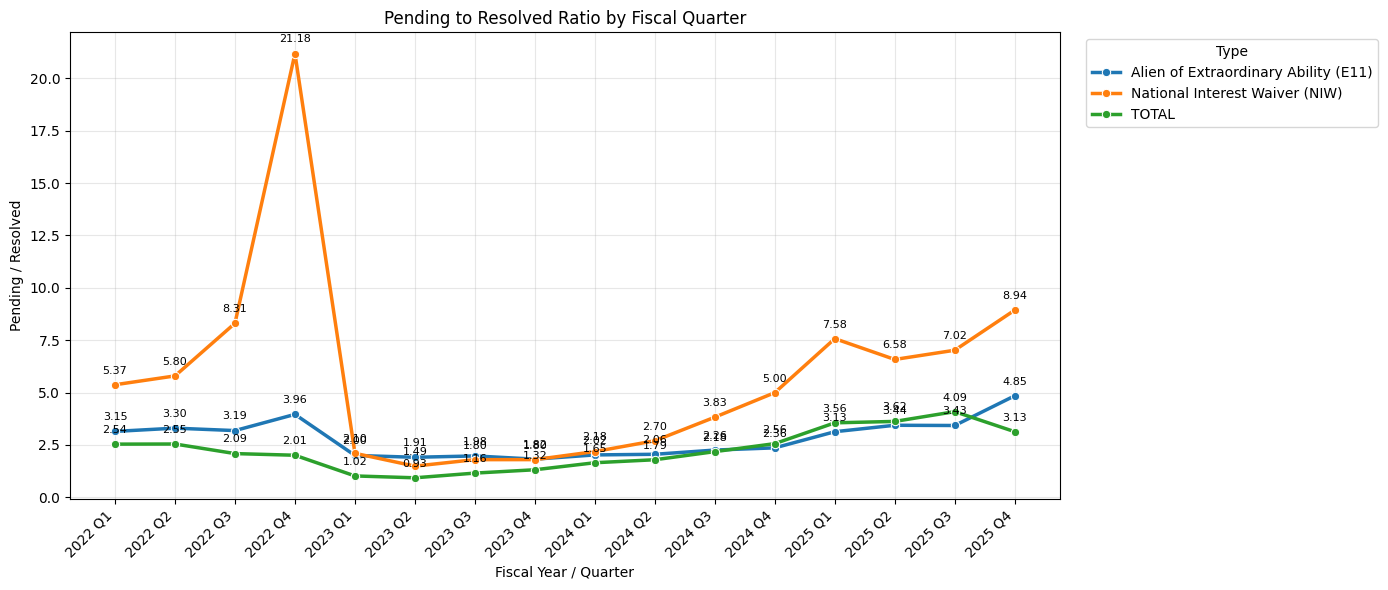

In [54]:
# А как служба справляется с pending?

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = df.copy()

df_plot['resolved'] = df_plot['approved'] + df_plot['denied']

df_plot['pending_to_resolved_ratio'] = (
    df_plot['pending']
    / df_plot['resolved'].replace(0, np.nan)
)

df_plot['fyq'] = (
    df_plot['fiscal_year'].astype(str)
    + ' Q'
    + df_plot['fiscal_quarter'].astype(str)
)

df_plot = df_plot.sort_values(['fiscal_year', 'fiscal_quarter', 'type'])

plt.figure(figsize=(14, 6))

ax = sns.lineplot(
    data=df_plot,
    x='fyq',
    y='pending_to_resolved_ratio',
    hue='type',
    marker='o',
    linewidth=2.5
)

for _, row in df_plot.iterrows():
    ax.annotate(
        f"{row['pending_to_resolved_ratio']:.2f}",
        xy=(row['fyq'], row['pending_to_resolved_ratio']),
        xytext=(0, 8),
        textcoords='offset points',
        ha='center',
        fontsize=8
    )

plt.title('Pending to Resolved Ratio by Fiscal Quarter')
plt.xlabel('Fiscal Year / Quarter')
plt.ylabel('Pending / Resolved')

plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.legend(title='Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [33]:

#Таблица на основании сводных данных
i140_yearly_total_eb1_eb2_snapshots = pd.read_csv(r'C:/Users/kelav/OneDrive/Документы/projects/uscis_analysis/data/analysis_tables/i140_yearly_total_eb1_eb2_snapshots.csv')
i140_yearly_total_eb1_eb2_snapshots['deny_approval_ratio'] = i140_yearly_total_eb1_eb2_snapshots.denied/i140_yearly_total_eb1_eb2_snapshots.approved


In [34]:
i140_yearly_total_eb1_eb2_snapshots

,fiscal_year,snapshot_type,is_actual,type,type_name,received,approved,denied,pending,approval_rate_received_basis,denial_rate_received_basis,approval_rate_decided_basis,denial_rate_decided_basis,pending_share,source_report_fiscal_year,source_report_quarter,source_file_names,deny_approval_ratio
0,2009,historic,f,EB1,First Preference,17238,13546,3630,62,0.785822,0.210581,0.788659,0.211341,0.003597,2019,4,I140_by_class_country_FY09_19.pdf,0.267976
1,2009,historic,f,EB2,Second Preference,19715,18270,1341,104,0.926706,0.068019,0.931620,0.068380,0.005275,2019,4,I140_by_class_country_FY09_19.pdf,0.073399
2,2009,historic,f,TOTAL,Total,57034,48375,8043,616,0.848178,0.141021,0.857439,0.142561,0.010801,2019,4,I140_by_class_country_FY09_19.pdf,0.166264
3,2010,historic,f,EB1,First Preference,17596,14269,3251,76,0.810923,0.184758,0.814441,0.185559,0.004319,2020,2,I140_rec_by_class_country_FY2020_Q1_Q2.pdf,0.227837
4,2010,historic,f,EB2,Second Preference,38398,35907,2317,174,0.935127,0.060342,0.939384,0.060616,0.004531,2020,2,I140_rec_by_class_country_FY2020_Q1_Q2.pdf,0.064528
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,2025,historic,f,EB2,Second Preference,116196,53624,8001,54571,0.461496,0.068858,0.870166,0.129834,0.469646,2025,4,i140_rec_by_class_country_fy2025_q4_v1.xlsx,0.149206
68,2025,historic,f,TOTAL,Total,244844,113417,14150,117277,0.463221,0.057792,0.889078,0.110922,0.478987,2025,4,i140_rec_by_class_country_fy2025_q4_v1.xlsx,0.124761
69,2025,actual,t,EB1,First Preference,51345,22431,5648,23266,0.436868,0.110001,0.798853,0.201147,0.453131,2025,4,i140_rec_by_class_country_fy2025_q4_v1.xlsx,0.251794
70,2025,actual,t,EB2,Second Preference,116196,53624,8001,54571,0.461496,0.068858,0.870166,0.129834,0.469646,2025,4,i140_rec_by_class_country_fy2025_q4_v1.xlsx,0.149206


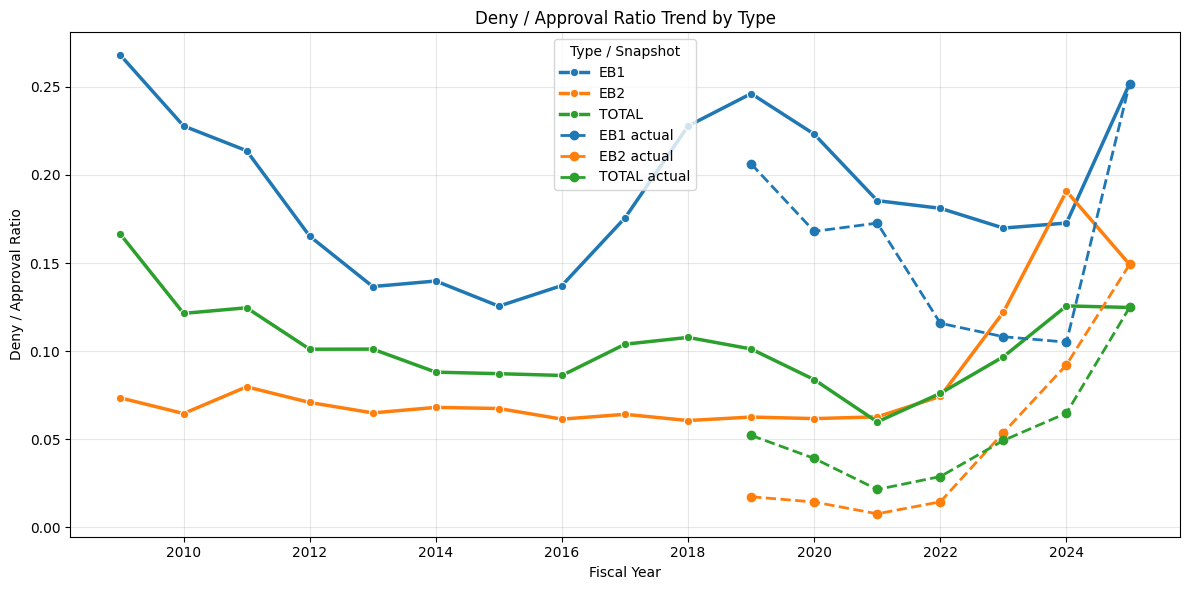

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = i140_yearly_total_eb1_eb2_snapshots.copy()

# если TOTAL не нужен на графике


historic = df_plot[df_plot['snapshot_type'].eq('historic')]
actual = df_plot[df_plot['snapshot_type'].eq('actual')]

types = sorted(df_plot['type'].unique())
palette = dict(zip(types, sns.color_palette('tab10', n_colors=len(types))))

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=historic,
    x='fiscal_year',
    y='deny_approval_ratio',
    hue='type',
    palette=palette,
    marker='o',
    linewidth=2.5
)

for t in types:
    actual_t = actual[actual['type'].eq(t)].sort_values('fiscal_year')
    plt.plot(
        actual_t['fiscal_year'],
        actual_t['deny_approval_ratio'],
        linestyle='--',
        marker='o',
        linewidth=2,
        color=palette[t],
        label=f'{t} actual'
    )

plt.title('Deny / Approval Ratio Trend by Type')
plt.xlabel('Fiscal Year')
plt.ylabel('Deny / Approval Ratio')
plt.grid(True, alpha=0.3)
plt.legend(title='Type / Snapshot')
plt.tight_layout()
plt.show()

In [40]:
# Вцелом на графиве видно, что по EB1 процент отказов выше. И второе - по всем со временем отказов становится больше - на актуальных данных (пунктиром) отказов меньше, потом их доля растет. 
i140_yearly_total_eb1_eb2_snapshots

,fiscal_year,snapshot_type,is_actual,type,type_name,received,approved,denied,pending,approval_rate_received_basis,denial_rate_received_basis,approval_rate_decided_basis,denial_rate_decided_basis,pending_share,source_report_fiscal_year,source_report_quarter,source_file_names,deny_approval_ratio
0,2009,historic,f,EB1,First Preference,17238,13546,3630,62,0.785822,0.210581,0.788659,0.211341,0.003597,2019,4,I140_by_class_country_FY09_19.pdf,0.267976
1,2009,historic,f,EB2,Second Preference,19715,18270,1341,104,0.926706,0.068019,0.931620,0.068380,0.005275,2019,4,I140_by_class_country_FY09_19.pdf,0.073399
2,2009,historic,f,TOTAL,Total,57034,48375,8043,616,0.848178,0.141021,0.857439,0.142561,0.010801,2019,4,I140_by_class_country_FY09_19.pdf,0.166264
3,2010,historic,f,EB1,First Preference,17596,14269,3251,76,0.810923,0.184758,0.814441,0.185559,0.004319,2020,2,I140_rec_by_class_country_FY2020_Q1_Q2.pdf,0.227837
4,2010,historic,f,EB2,Second Preference,38398,35907,2317,174,0.935127,0.060342,0.939384,0.060616,0.004531,2020,2,I140_rec_by_class_country_FY2020_Q1_Q2.pdf,0.064528
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,2025,historic,f,EB2,Second Preference,116196,53624,8001,54571,0.461496,0.068858,0.870166,0.129834,0.469646,2025,4,i140_rec_by_class_country_fy2025_q4_v1.xlsx,0.149206
68,2025,historic,f,TOTAL,Total,244844,113417,14150,117277,0.463221,0.057792,0.889078,0.110922,0.478987,2025,4,i140_rec_by_class_country_fy2025_q4_v1.xlsx,0.124761
69,2025,actual,t,EB1,First Preference,51345,22431,5648,23266,0.436868,0.110001,0.798853,0.201147,0.453131,2025,4,i140_rec_by_class_country_fy2025_q4_v1.xlsx,0.251794
70,2025,actual,t,EB2,Second Preference,116196,53624,8001,54571,0.461496,0.068858,0.870166,0.129834,0.469646,2025,4,i140_rec_by_class_country_fy2025_q4_v1.xlsx,0.149206


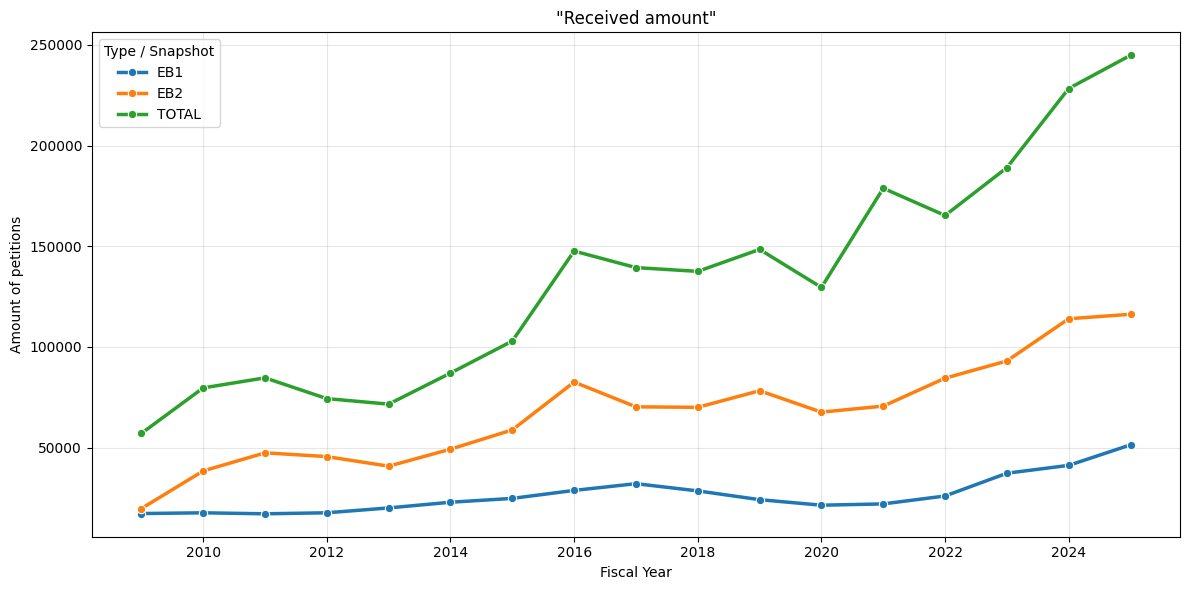

In [41]:
df_plot = i140_yearly_total_eb1_eb2_snapshots.copy()


types = sorted(df_plot['type'].unique())
palette = dict(zip(types, sns.color_palette('tab10', n_colors=len(types))))

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=historic,
    x='fiscal_year',
    y='received',
    hue='type',
    palette=palette,
    marker='o',
    linewidth=2.5
)

plt.title('"Received amount"')
plt.xlabel('Fiscal Year')
plt.ylabel('Amount of petitions')
plt.grid(True, alpha=0.3)
plt.legend(title='Type / Snapshot')
plt.tight_layout()
plt.show()

In [42]:
#Теперь попробуем понять, насколько отличается вероятность одобрения у pending кейсов - предполагаем, что значительную часть
# состаляет RFE
import numpy as np
import pandas as pd

base = i140_yearly_total_eb1_eb2_snapshots.copy()

# Оставляем только пары actual/historic по одному fiscal_year + type
paired = (
    base
    .pivot_table(
        index=['fiscal_year', 'type', 'type_name'],
        columns='snapshot_type',
        values=['received', 'approved', 'denied', 'pending', 'deny_approval_ratio'],
        aggfunc='first'
    )
)

paired.columns = [f'{metric}_{snapshot}' for metric, snapshot in paired.columns]
paired = paired.reset_index()

# Оставляем только строки, где есть и actual, и historic
changed = paired.dropna(
    subset=[
        'pending_actual', 'pending_historic',
        'approved_actual', 'approved_historic',
        'denied_actual', 'denied_historic'
    ]
).copy()

# Абсолютные изменения
changed['pending_decrease'] = changed['pending_actual'] - changed['pending_historic']
changed['approved_increase'] = changed['approved_historic'] - changed['approved_actual']
changed['denied_increase'] = changed['denied_historic'] - changed['denied_actual']

# Оставляем только случаи, где pending реально уменьшился
changed = changed[changed['pending_decrease'] > 0].copy()

# Ratio по приросту решений: сколько новых отказов на одно новое одобрение
changed['new_deny_approval_ratio'] = (
    changed['denied_increase'] / changed['approved_increase'].replace(0, np.nan)
)

# Доли новых отказов и одобрений внутри уменьшившегося pending
changed['denied_share_of_pending_decrease'] = (
    changed['denied_increase'] / changed['pending_decrease']
)

changed['approved_share_of_pending_decrease'] = (
    changed['approved_increase'] / changed['pending_decrease']
)

# На сколько процентов уменьшился pending относительно actual pending
changed['pending_decrease_pct_of_actual'] = (
    changed['pending_decrease'] / changed['pending_actual'].replace(0, np.nan)
)

# Проверочная колонка: насколько прирост approvals + denials объясняет снижение pending
changed['resolved_share_of_pending_decrease'] = (
    (changed['approved_increase'] + changed['denied_increase'])
    / changed['pending_decrease']
)

# Опционально: разница между тем, что ушло из pending, и тем, что прибавилось к approvals/denials
changed['pending_decrease_unexplained'] = (
    changed['pending_decrease']
    - changed['approved_increase']
    - changed['denied_increase']
)

changed = changed[
    [
        'fiscal_year',
        'type',
        'type_name',

        'received_actual',
        'received_historic',

        'pending_actual',
        'pending_historic',
        'pending_decrease',
        'pending_decrease_pct_of_actual',

        'approved_actual',
        'approved_historic',
        'approved_increase',

        'denied_actual',
        'denied_historic',
        'denied_increase',

        'deny_approval_ratio_actual',
        'deny_approval_ratio_historic',
        'new_deny_approval_ratio',

        'approved_share_of_pending_decrease',
        'denied_share_of_pending_decrease',
        'resolved_share_of_pending_decrease',
        'pending_decrease_unexplained'
    ]
].sort_values(['type', 'fiscal_year'])

changed

,fiscal_year,type,type_name,received_actual,received_historic,pending_actual,pending_historic,pending_decrease,pending_decrease_pct_of_actual,approved_actual,...,denied_actual,denied_historic,denied_increase,deny_approval_ratio_actual,deny_approval_ratio_historic,new_deny_approval_ratio,approved_share_of_pending_decrease,denied_share_of_pending_decrease,resolved_share_of_pending_decrease,pending_decrease_unexplained
30,2019,EB1,First Preference,24170.0,24129.0,9371.0,61.0,9310.0,0.993491,12268.0,...,2531.0,4755.0,2224.0,0.206309,0.246207,0.315685,0.756713,0.238883,0.995596,41.0
33,2020,EB1,First Preference,21407.0,21376.0,7674.0,66.0,7608.0,0.991400,11758.0,...,1975.0,3888.0,1913.0,0.167971,0.223166,0.337747,0.744479,0.251446,0.995925,31.0
36,2021,EB1,First Preference,22020.0,22021.0,12899.0,117.0,12782.0,0.990930,7778.0,...,1343.0,3426.0,2083.0,0.172666,0.185410,0.194673,0.837115,0.162964,1.000078,-1.0
39,2022,EB1,First Preference,25950.0,25953.0,6049.0,234.0,5815.0,0.961316,17836.0,...,2065.0,3943.0,1878.0,0.115777,0.181071,0.476650,0.677558,0.322958,1.000516,-3.0
42,2023,EB1,First Preference,36978.0,37259.0,10102.0,1098.0,9004.0,0.891309,24253.0,...,2623.0,5250.0,2627.0,0.108152,0.169842,0.394563,0.739449,0.291759,1.031208,-281.0
45,2024,EB1,First Preference,41164.0,41164.0,14693.0,8101.0,6592.0,0.448649,23954.0,...,2517.0,4869.0,2352.0,0.105076,0.172696,0.554717,0.643204,0.356796,1.000000,0.0
31,2019,EB2,Second Preference,78209.0,78232.0,12044.0,265.0,11779.0,0.977997,65042.0,...,1123.0,4588.0,3465.0,0.017266,0.062525,0.415617,0.707785,0.294168,1.001953,-23.0
34,2020,EB2,Second Preference,67592.0,67606.0,17882.0,272.0,17610.0,0.984789,49010.0,...,700.0,3910.0,3210.0,0.014283,0.061649,0.222700,0.818512,0.182283,1.000795,-14.0
37,2021,EB2,Second Preference,70550.0,70598.0,27541.0,299.0,27242.0,0.989143,42685.0,...,324.0,4144.0,3820.0,0.007590,0.062641,0.162761,0.861537,0.140225,1.001762,-48.0
40,2022,EB2,Second Preference,84425.0,84473.0,12371.0,388.0,11983.0,0.968636,71031.0,...,1023.0,5813.0,4790.0,0.014402,0.074267,0.661511,0.604273,0.399733,1.004006,-48.0


In [43]:
#Создадим агрегированную таблицу, касающуюся только данных, на которые изменились actual в historic. Напомню, что historic - по 
# 4 кварталу 2025, тогда как actual - на момент публикации актуального отчета за соответствующий год (4 квартал)

import numpy as np
import pandas as pd

base = i140_yearly_total_eb1_eb2_snapshots.copy()

paired = (
    base
    .pivot_table(
        index=['fiscal_year', 'type', 'type_name'],
        columns='snapshot_type',
        values=[
            'approved',
            'denied',
            'pending',
            'approval_rate_decided_basis',
            'denial_rate_decided_basis',
            'deny_approval_ratio'
        ],
        aggfunc='first'
    )
)

paired.columns = [f'{metric}_{snapshot}' for metric, snapshot in paired.columns]
paired = paired.reset_index()

df_changed_rates = paired.dropna(
    subset=[
        'approved_actual',
        'approved_historic',
        'denied_actual',
        'denied_historic',
        'pending_actual',
        'pending_historic'
    ]
).copy()

df_changed_rates['pending_decrease'] = (
    df_changed_rates['pending_actual']
    - df_changed_rates['pending_historic']
)

df_changed_rates['changed_approved'] = (
    df_changed_rates['approved_historic']
    - df_changed_rates['approved_actual']
)

df_changed_rates['changed_denied'] = (
    df_changed_rates['denied_historic']
    - df_changed_rates['denied_actual']
)

df_changed_rates = df_changed_rates[df_changed_rates['pending_decrease'] > 0].copy()

df_changed_rates['changed_denial_rate'] = (
    df_changed_rates['changed_denied']
    / df_changed_rates['pending_decrease'].replace(0, np.nan)
)

df_changed_rates['changed_approval_rate'] = (
    df_changed_rates['changed_approved']
    / df_changed_rates['pending_decrease'].replace(0, np.nan)
)

df_changed_rates['changed_deny_approval_ratio'] = (
    df_changed_rates['changed_denied']
    / df_changed_rates['changed_approved'].replace(0, np.nan)
)

df_changed_rates['denial_rate_diff_vs_actual_pct'] = (
    (
        df_changed_rates['changed_denial_rate']
        - df_changed_rates['denial_rate_decided_basis_actual']
    )
    / df_changed_rates['denial_rate_decided_basis_actual'].replace(0, np.nan)
)

df_changed_rates['approval_rate_diff_vs_actual_pct'] = (
    (
        df_changed_rates['changed_approval_rate']
        - df_changed_rates['approval_rate_decided_basis_actual']
    )
    / df_changed_rates['approval_rate_decided_basis_actual'].replace(0, np.nan)
)

df_changed_rates['deny_approval_ratio_diff_vs_actual_pct'] = (
    (
        df_changed_rates['changed_deny_approval_ratio']
        - df_changed_rates['deny_approval_ratio_actual']
    )
    / df_changed_rates['deny_approval_ratio_actual'].replace(0, np.nan)
)

df_changed_rates = df_changed_rates[
    [
        'fiscal_year',
        'type',
        'type_name',

        'pending_actual',
        'pending_historic',
        'pending_decrease',

        'changed_approved',
        'changed_denied',

        'changed_approval_rate',
        'changed_denial_rate',
        'changed_deny_approval_ratio',

        'approval_rate_decided_basis_actual',
        'denial_rate_decided_basis_actual',
        'deny_approval_ratio_actual',

        'approval_rate_diff_vs_actual_pct',
        'denial_rate_diff_vs_actual_pct',
        'deny_approval_ratio_diff_vs_actual_pct'
    ]
].sort_values(['type', 'fiscal_year'])

df_changed_rates

,fiscal_year,type,type_name,pending_actual,pending_historic,pending_decrease,changed_approved,changed_denied,changed_approval_rate,changed_denial_rate,changed_deny_approval_ratio,approval_rate_decided_basis_actual,denial_rate_decided_basis_actual,deny_approval_ratio_actual,approval_rate_diff_vs_actual_pct,denial_rate_diff_vs_actual_pct,deny_approval_ratio_diff_vs_actual_pct
30,2019,EB1,First Preference,9371.0,61.0,9310.0,7045.0,2224.0,0.756713,0.238883,0.315685,0.828975,0.171025,0.206309,-0.087170,0.396771,0.530155
33,2020,EB1,First Preference,7674.0,66.0,7608.0,5664.0,1913.0,0.744479,0.251446,0.337747,0.856186,0.143814,0.167971,-0.130470,0.748408,1.010750
36,2021,EB1,First Preference,12899.0,117.0,12782.0,10700.0,2083.0,0.837115,0.162964,0.194673,0.852757,0.147243,0.172666,-0.018344,0.106769,0.127450
39,2022,EB1,First Preference,6049.0,234.0,5815.0,3940.0,1878.0,0.677558,0.322958,0.476650,0.896236,0.103764,0.115777,-0.243996,2.112438,3.116961
42,2023,EB1,First Preference,10102.0,1098.0,9004.0,6658.0,2627.0,0.739449,0.291759,0.394563,0.902404,0.097596,0.108152,-0.180578,1.989447,2.648240
45,2024,EB1,First Preference,14693.0,8101.0,6592.0,4240.0,2352.0,0.643204,0.356796,0.554717,0.904915,0.095085,0.105076,-0.289211,2.752384,4.279178
31,2019,EB2,Second Preference,12044.0,265.0,11779.0,8337.0,3465.0,0.707785,0.294168,0.415617,0.983027,0.016973,0.017266,-0.279995,16.331788,23.071745
34,2020,EB2,Second Preference,17882.0,272.0,17610.0,14414.0,3210.0,0.818512,0.182283,0.222700,0.985918,0.014082,0.014283,-0.169797,11.944682,14.592192
37,2021,EB2,Second Preference,27541.0,299.0,27242.0,23470.0,3820.0,0.861537,0.140225,0.162761,0.992467,0.007533,0.007590,-0.131923,17.613957,20.442753
40,2022,EB2,Second Preference,12371.0,388.0,11983.0,7241.0,4790.0,0.604273,0.399733,0.661511,0.985802,0.014198,0.014402,-0.387024,27.154798,44.931355


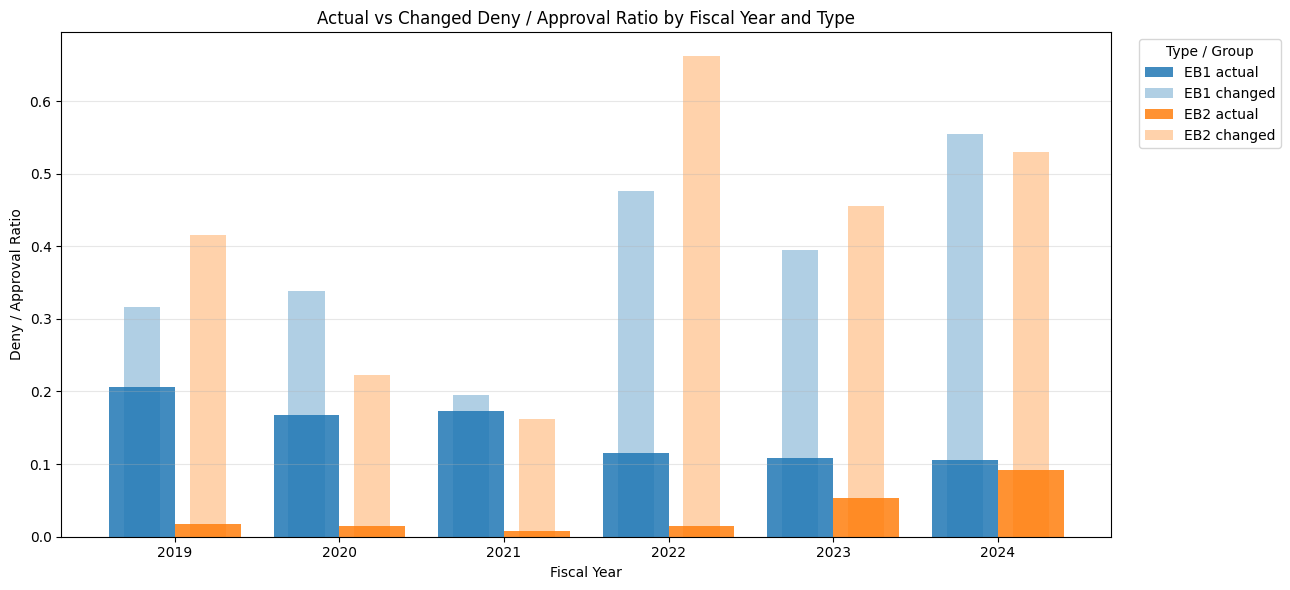

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = df_changed_rates.copy()

# если TOTAL не нужен
plot_df = plot_df[plot_df['type'].ne('TOTAL')].copy()

plot_df = plot_df.sort_values(['fiscal_year', 'type'])

years = sorted(plot_df['fiscal_year'].unique())
types = sorted(plot_df['type'].unique())

x = np.arange(len(years))
bar_width = 0.8 / len(types)

palette = dict(zip(types, sns.color_palette('tab10', n_colors=len(types))))

plt.figure(figsize=(13, 6))

for i, t in enumerate(types):
    type_df = (
        plot_df[plot_df['type'].eq(t)]
        .set_index('fiscal_year')
        .reindex(years)
    )

    offset = (i - (len(types) - 1) / 2) * bar_width

    # Actual: основной столбец
    plt.bar(
        x + offset,
        type_df['deny_approval_ratio_actual'],
        width=bar_width,
        color=palette[t],
        alpha=0.85,
        label=f'{t} actual'
    )

    # Changed: более блеклый столбец поверх/внутри того же места
    plt.bar(
        x + offset,
        type_df['changed_deny_approval_ratio'],
        width=bar_width * 0.55,
        color=palette[t],
        alpha=0.35,
        label=f'{t} changed'
    )

plt.title('Actual vs Changed Deny / Approval Ratio by Fiscal Year and Type')
plt.xlabel('Fiscal Year')
plt.ylabel('Deny / Approval Ratio')

plt.xticks(x, years)
plt.grid(axis='y', alpha=0.3)

plt.legend(title='Type / Group', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
#График показывает разницу между deny|approval ratio между теми решениями, которые приняты сразу, и теми, которые приняты спустя время. Чем выше показатель, тем выше доля
#отказов. Видно, что у pending шанс получить отказ в разы выше

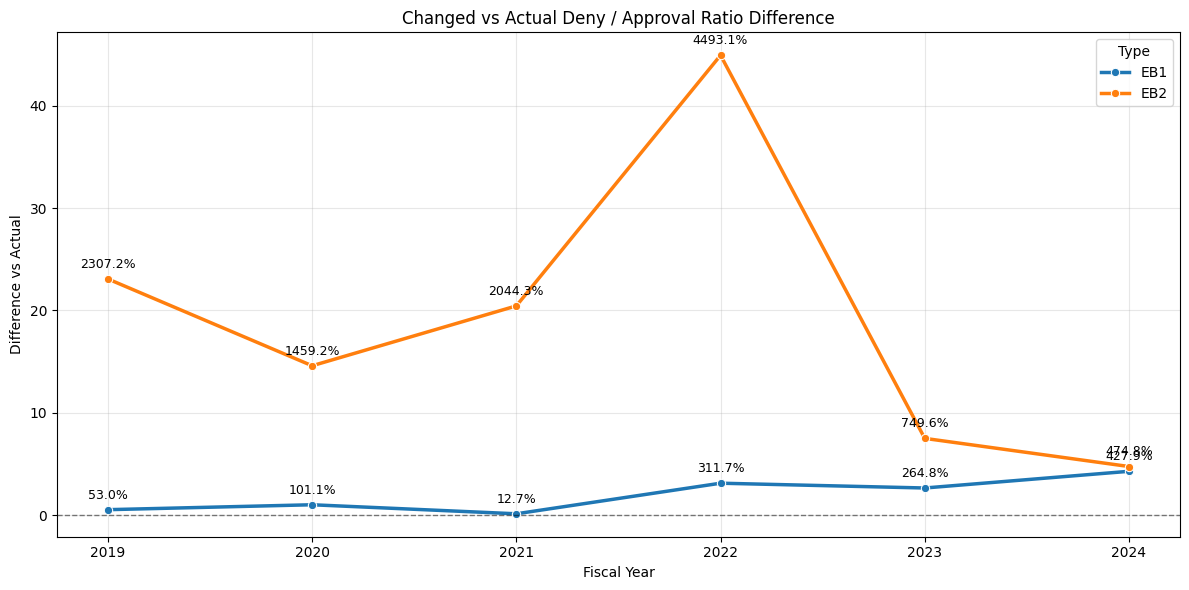

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = df_changed_rates.copy()

# если TOTAL не нужен
plot_df = plot_df[plot_df['type'].ne('TOTAL')].copy()

plot_df = plot_df.sort_values(['type', 'fiscal_year'])

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=plot_df,
    x='fiscal_year',
    y='deny_approval_ratio_diff_vs_actual_pct',
    hue='type',
    marker='o',
    linewidth=2.5
)

# подписи процентов на точках
for _, row in plot_df.iterrows():
    ax.annotate(
        f"{row['deny_approval_ratio_diff_vs_actual_pct']:.1%}",
        xy=(row['fiscal_year'], row['deny_approval_ratio_diff_vs_actual_pct']),
        xytext=(0, 8),
        textcoords='offset points',
        ha='center',
        fontsize=9
    )

ax.axhline(0, linewidth=1, linestyle='--', color='black', alpha=0.5)

plt.title('Changed vs Actual Deny / Approval Ratio Difference')
plt.xlabel('Fiscal Year')
plt.ylabel('Difference vs Actual')

plt.xticks(sorted(plot_df['fiscal_year'].unique()))
plt.grid(True, alpha=0.3)
plt.legend(title='Type')
plt.tight_layout()
plt.show()

In [46]:
import numpy as np
import pandas as pd

df_denial_factor = df_changed_rates.copy()

# если TOTAL не нужен
df_denial_factor = df_denial_factor[df_denial_factor['type'].ne('TOTAL')].copy()

df_denial_factor['denial_rate_lift_factor'] = (
    df_denial_factor['changed_denial_rate']
    / df_denial_factor['denial_rate_decided_basis_actual'].replace(0, np.nan)
)

df_denial_factor['denial_rate_lift_pct'] = (
    df_denial_factor['denial_rate_lift_factor'] - 1
)

df_denial_factor = df_denial_factor[
    [
        'fiscal_year',
        'type',
        'type_name',

        'pending_decrease',
        'changed_denied',
        'changed_approved',

        'denial_rate_decided_basis_actual',
        'changed_denial_rate',

        'denial_rate_lift_factor',
        'denial_rate_lift_pct'
    ]
].sort_values(['type', 'fiscal_year'])

df_denial_factor

,fiscal_year,type,type_name,pending_decrease,changed_denied,changed_approved,denial_rate_decided_basis_actual,changed_denial_rate,denial_rate_lift_factor,denial_rate_lift_pct
30,2019,EB1,First Preference,9310.0,2224.0,7045.0,0.171025,0.238883,1.396771,0.396771
33,2020,EB1,First Preference,7608.0,1913.0,5664.0,0.143814,0.251446,1.748408,0.748408
36,2021,EB1,First Preference,12782.0,2083.0,10700.0,0.147243,0.162964,1.106769,0.106769
39,2022,EB1,First Preference,5815.0,1878.0,3940.0,0.103764,0.322958,3.112438,2.112438
42,2023,EB1,First Preference,9004.0,2627.0,6658.0,0.097596,0.291759,2.989447,1.989447
45,2024,EB1,First Preference,6592.0,2352.0,4240.0,0.095085,0.356796,3.752384,2.752384
31,2019,EB2,Second Preference,11779.0,3465.0,8337.0,0.016973,0.294168,17.331788,16.331788
34,2020,EB2,Second Preference,17610.0,3210.0,14414.0,0.014082,0.182283,12.944682,11.944682
37,2021,EB2,Second Preference,27242.0,3820.0,23470.0,0.007533,0.140225,18.613957,17.613957
40,2022,EB2,Second Preference,11983.0,4790.0,7241.0,0.014198,0.399733,28.154798,27.154798


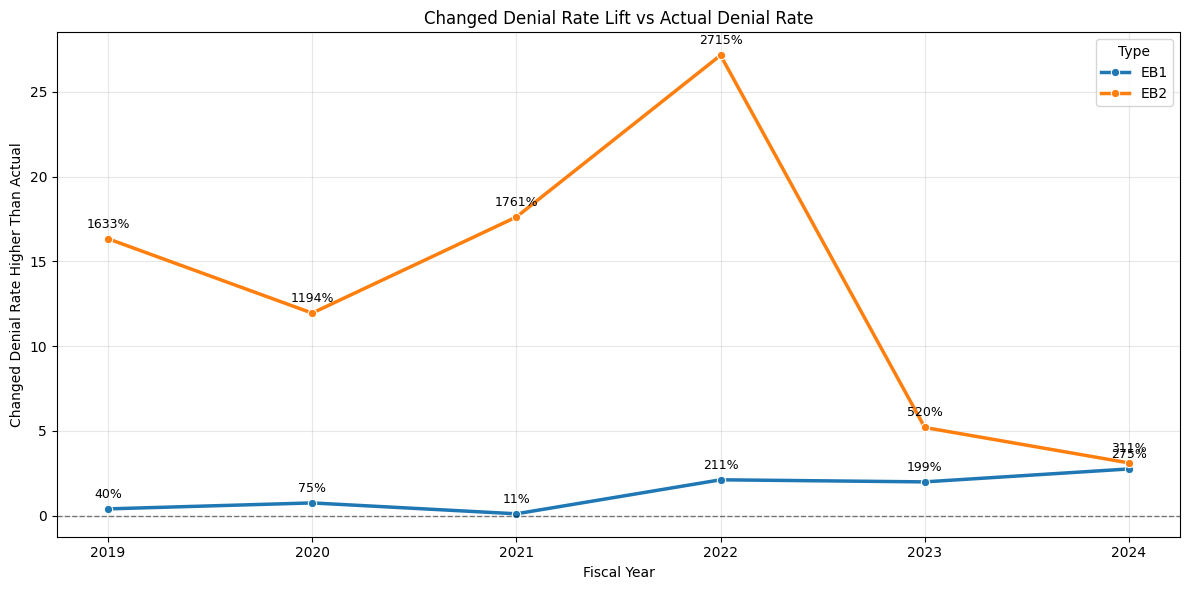

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = df_denial_factor.copy()

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=plot_df,
    x='fiscal_year',
    y='denial_rate_lift_pct',
    hue='type',
    marker='o',
    linewidth=2.5
)

for _, row in plot_df.iterrows():
    ax.annotate(
        f"{row['denial_rate_lift_pct']:.0%}",
        xy=(row['fiscal_year'], row['denial_rate_lift_pct']),
        xytext=(0, 8),
        textcoords='offset points',
        ha='center',
        fontsize=9
    )

ax.axhline(0, linestyle='--', linewidth=1, color='black', alpha=0.5)

plt.title('Changed Denial Rate Lift vs Actual Denial Rate')
plt.xlabel('Fiscal Year')
plt.ylabel('Changed Denial Rate Higher Than Actual')

plt.xticks(sorted(plot_df['fiscal_year'].unique()))
plt.grid(True, alpha=0.3)
plt.legend(title='Type')
plt.tight_layout()
plt.show()

In [49]:
import numpy as np
import pandas as pd

base = i140_yearly_total_eb1_eb2_snapshots.copy()

paired = (
    base
    .pivot_table(
        index=['fiscal_year', 'type', 'type_name'],
        columns='snapshot_type',
        values=['received', 'denied', 'approved', 'pending'],
        aggfunc='first'
    )
)

paired.columns = [f'{metric}_{snapshot}' for metric, snapshot in paired.columns]
paired = paired.reset_index()

denial_summary = paired.dropna(
    subset=[
        'received_actual',
        'received_historic',
        'denied_actual',
        'denied_historic',
        'approved_actual',
        'approved_historic',
        'pending_actual',
        'pending_historic'
    ]
).copy()

denial_summary['pending_decrease'] = (
    denial_summary['pending_actual']
    - denial_summary['pending_historic']
)

denial_summary['changed_denied'] = (
    denial_summary['denied_historic']
    - denial_summary['denied_actual']
)

denial_summary = denial_summary[denial_summary['pending_decrease'] > 0].copy()

# 1. Процент отказов от received в actual
denial_summary['denial_pct_of_received_actual'] = (
    denial_summary['denied_actual']
    / denial_summary['received_actual'].replace(0, np.nan)
    * 100
)

# 2. Процент отказов от changed, где changed = уменьшение pending
denial_summary['denial_pct_of_changed'] = (
    denial_summary['changed_denied']
    / denial_summary['pending_decrease'].replace(0, np.nan)
    * 100
)

# 3. Изменение процента отказов в historic по сравнению с actual, в процентных пунктах
denial_summary['historic_vs_actual_denial_pct_change_pp'] = (
    (
        denial_summary['denied_historic']
        / denial_summary['received_historic'].replace(0, np.nan)
        * 100
    )
    -
    (
        denial_summary['denied_actual']
        / denial_summary['received_actual'].replace(0, np.nan)
        * 100
    )
)

denial_summary = denial_summary[
    [
        'fiscal_year',
        'type',
        'type_name',
        'denial_pct_of_received_actual',
        'denial_pct_of_changed',
        'historic_vs_actual_denial_pct_change_pp'
    ]
].sort_values(['fiscal_year', 'type'])

denial_summary

denial_summary[
    [
        'denial_pct_of_received_actual',
        'denial_pct_of_changed',
        'historic_vs_actual_denial_pct_change_pp'
    ]
] = denial_summary[
    [
        'denial_pct_of_received_actual',
        'denial_pct_of_changed',
        'historic_vs_actual_denial_pct_change_pp'
    ]
].round(2)

denial_summary

,fiscal_year,type,type_name,denial_pct_of_received_actual,denial_pct_of_changed,historic_vs_actual_denial_pct_change_pp
30,2019,EB1,First Preference,10.47,23.89,9.23
31,2019,EB2,Second Preference,1.44,29.42,4.43
32,2019,TOTAL,Total,4.05,28.69,5.10
33,2020,EB1,First Preference,9.23,25.14,8.96
34,2020,EB2,Second Preference,1.04,18.23,4.75
35,2020,TOTAL,Total,2.79,19.51,4.90
36,2021,EB1,First Preference,6.10,16.30,9.46
37,2021,EB2,Second Preference,0.46,14.02,5.41
38,2021,TOTAL,Total,1.27,11.14,4.35
39,2022,EB1,First Preference,7.96,32.30,7.24


In [50]:
#теперь применим rate к totals, чтобы рассчитать более приближенный к реальности denial rate в 2025 году.

In [51]:
import numpy as np
import pandas as pd

# 1. Берем коэффициенты из df_changed_rates
changed_coeffs = df_changed_rates[
    [
        'fiscal_year',
        'type',
        'changed_deny_approval_ratio'
    ]
].copy()

changed_coeffs = changed_coeffs.rename(columns={
    'type': 'changed_type',
    'changed_deny_approval_ratio': 'projected_changed_deny_approval_ratio'
})

# 2. Для 2025 используем коэффициент 2024
coeff_2025 = changed_coeffs[
    changed_coeffs['fiscal_year'].eq(2024)
].copy()

coeff_2025['fiscal_year'] = 2025

changed_coeffs = pd.concat(
    [changed_coeffs, coeff_2025],
    ignore_index=True
)

# 3. Маппим категории df_totals на EB1 / EB2 / TOTAL из df_changed_rates
df_projected = df_totals.copy()

type_map = {
    'Alien of Extraordinary Ability (E11)': 'EB1',
    'National Interest Waiver (NIW)': 'EB2',
    'TOTAL': 'TOTAL'
}

df_projected['changed_type'] = df_projected['type'].map(type_map)

# 4. Приклеиваем changed deny/approval ratio по году и типу
df_projected = df_projected.merge(
    changed_coeffs,
    on=['fiscal_year', 'changed_type'],
    how='left',
    validate='m:1'
)

# 5. Из deny/approval ratio получаем projected split rates для pending
df_projected['projected_denial_rate_from_pending'] = (
    df_projected['projected_changed_deny_approval_ratio']
    / (1 + df_projected['projected_changed_deny_approval_ratio'])
)

df_projected['projected_approval_rate_from_pending'] = (
    1
    / (1 + df_projected['projected_changed_deny_approval_ratio'])
)

# 6. Считаем projected approvals / denials из текущего pending
df_projected['projected_approved_from_pending'] = (
    df_projected['pending']
    * df_projected['projected_approval_rate_from_pending']
)

df_projected['projected_denied_from_pending'] = (
    df_projected['pending']
    * df_projected['projected_denial_rate_from_pending']
)

# 7. Опционально: прогноз итоговых approved / denied после дозревания pending
df_projected['projected_total_approved'] = (
    df_projected['approved']
    + df_projected['projected_approved_from_pending']
)

df_projected['projected_total_denied'] = (
    df_projected['denied']
    + df_projected['projected_denied_from_pending']
)

df_projected['projected_total_deny_approval_ratio'] = (
    df_projected['projected_total_denied']
    / df_projected['projected_total_approved'].replace(0, np.nan)
)

# 8. Для читаемости: проценты и округление counts
rate_cols = [
    'projected_approval_rate_from_pending',
    'projected_denial_rate_from_pending'
]

df_projected[rate_cols] = df_projected[rate_cols] * 100

count_cols = [
    'projected_approved_from_pending',
    'projected_denied_from_pending',
    'projected_total_approved',
    'projected_total_denied'
]

df_projected[count_cols] = df_projected[count_cols].round(0).astype('Int64')

df_projected[
    [
        'fiscal_year',
        'type',
        'changed_type',

        'received',
        'approved',
        'denied',
        'pending',

        'projected_changed_deny_approval_ratio',
        'projected_approval_rate_from_pending',
        'projected_denial_rate_from_pending',

        'projected_approved_from_pending',
        'projected_denied_from_pending',

        'projected_total_approved',
        'projected_total_denied',
        'projected_total_deny_approval_ratio'
    ]
].sort_values(['fiscal_year', 'changed_type'])

,fiscal_year,type,changed_type,received,approved,denied,pending,projected_changed_deny_approval_ratio,projected_approval_rate_from_pending,projected_denial_rate_from_pending,projected_approved_from_pending,projected_denied_from_pending,projected_total_approved,projected_total_denied,projected_total_deny_approval_ratio
0,2022,Alien of Extraordinary Ability (E11),EB1,10481,5623,1608,24406,0.476650,67.720866,32.279134,16528,7878,22151,9486,0.428245
4,2022,National Interest Waiver (NIW),EB2,21973,10316,468,80546,0.661511,60.186186,39.813814,48478,32068,58794,32536,0.553401
8,2022,TOTAL,TOTAL,165300,139644,4003,333291,0.600888,62.465347,37.534653,208191,125100,347835,129103,0.371160
1,2023,Alien of Extraordinary Ability (E11),EB1,15905,10356,4156,27892,0.394563,71.707054,28.292946,20001,7891,30357,12047,0.396866
5,2023,National Interest Waiver (NIW),EB2,39803,31889,8172,71413,0.456048,68.679058,31.320942,49046,22367,80935,30539,0.377331
9,2023,TOTAL,TOTAL,189028,168590,19637,207658,0.326778,75.370558,24.629442,156513,51145,325103,70782,0.217722
2,2024,Alien of Extraordinary Ability (E11),EB1,20166,12231,4703,36876,0.554717,64.320388,35.679612,23719,13157,35950,17860,0.496810
6,2024,National Interest Waiver (NIW),EB2,63549,27526,11256,129661,0.529958,65.361273,34.638727,84748,44913,112274,56169,0.500284
10,2024,TOTAL,TOTAL,228298,159106,19961,366058,0.350901,74.024667,25.975333,270973,95085,430079,115046,0.267499
3,2025,Alien of Extraordinary Ability (E11),EB1,29582,12468,6165,68857,0.554717,64.320388,35.679612,44289,24568,56757,30733,0.541481


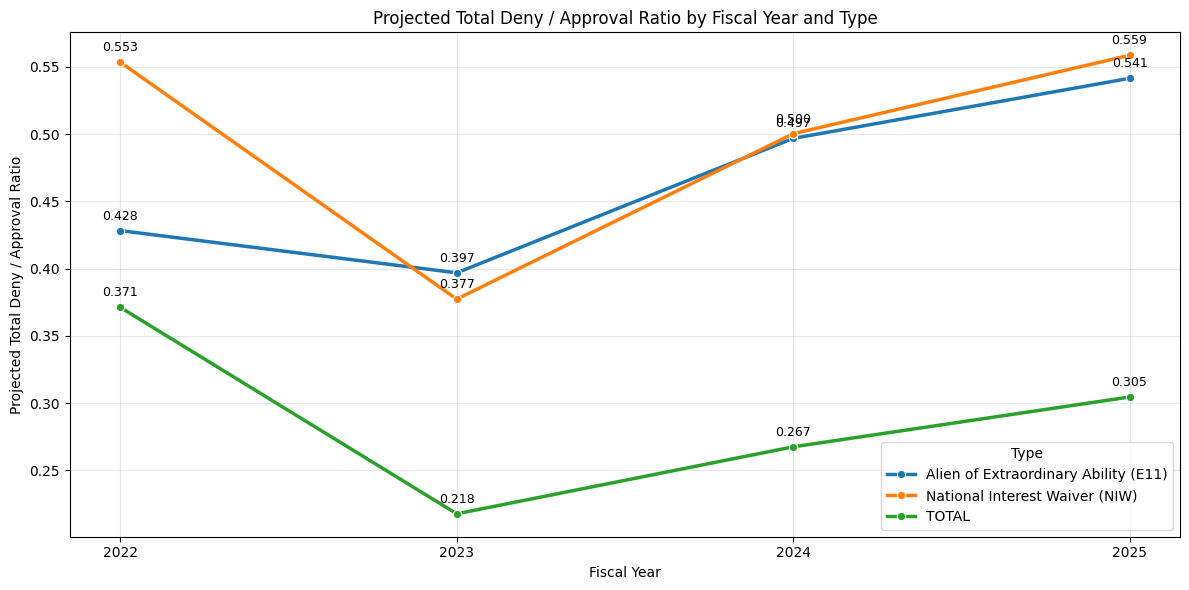

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = df_projected.copy()

plot_df = plot_df.sort_values(['type', 'fiscal_year'])

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=plot_df,
    x='fiscal_year',
    y='projected_total_deny_approval_ratio',
    hue='type',
    marker='o',
    linewidth=2.5
)

for _, row in plot_df.iterrows():
    ax.annotate(
        f"{row['projected_total_deny_approval_ratio']:.3f}",
        xy=(row['fiscal_year'], row['projected_total_deny_approval_ratio']),
        xytext=(0, 8),
        textcoords='offset points',
        ha='center',
        fontsize=9
    )

plt.title('Projected Total Deny / Approval Ratio by Fiscal Year and Type')
plt.xlabel('Fiscal Year')
plt.ylabel('Projected Total Deny / Approval Ratio')

plt.xticks(sorted(plot_df['fiscal_year'].unique()))
plt.grid(True, alpha=0.3)
plt.legend(title='Type')
plt.tight_layout()
plt.show()